# 2. Exploratory Data Analysis (EDA)

**Objective:** Understand the data deeply before modeling — discover patterns, distributions, and feature relationships that will guide our model choices.

**Key questions:**
1. How severe is the class imbalance?
2. Do fraud transactions have different amount profiles?
3. Are fraud transactions concentrated at certain times of day?
4. Which PCA features best separate fraud from normal?
5. Are there correlations we should be aware of?


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.dpi"       : 110,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
})

PALETTE = {"normal": "#3a86ff", "fraud": "#ff006e"}

print("Libraries loaded ✓")


Libraries loaded ✓


In [29]:
DATA_PATH = Path("../data/raw/creditcard.csv")
df = pd.read_csv(DATA_PATH)

# Add engineered EDA features BEFORE creating normal/fraud subsets
df["Hour"] = (df["Time"] / 3600) % 24
df["LogAmount"] = np.log1p(df["Amount"])

normal_df = df[df["Class"] == 0].copy()
fraud_df  = df[df["Class"] == 1].copy()

print(f"Total rows      : {len(df):,}")
print(f"Normal txns     : {len(normal_df):,}")
print(f"Fraud txns      : {len(fraud_df):,}")
print(f"Fraud rate      : {df['Class'].mean()*100:.4f}%")

Total rows      : 284,807
Normal txns     : 284,315
Fraud txns      : 492
Fraud rate      : 0.1727%


In [30]:
display(normal_df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,LogAmount
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,0.0000,5.0148
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,0.0000,1.3056
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,0.0003,5.9393
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0,0.0003,4.8243
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0,0.0006,4.2625


## 2.1 Load Dataset

In [31]:
DATA_PATH = Path("../data/raw/creditcard.csv")
df = pd.read_csv(DATA_PATH)

# Re-add engineered features so downstream cells can reference them
df["Hour"]      = (df["Time"] / 3600) % 24
df["LogAmount"] = np.log1p(df["Amount"])

normal_df = df[df["Class"] == 0].copy()
fraud_df  = df[df["Class"] == 1].copy()

print(f"Total rows      : {len(df):,}")
print(f"Normal txns     : {len(normal_df):,}")
print(f"Fraud txns      : {len(fraud_df):,}")
print(f"Fraud rate      : {len(fraud_df)/len(df)*100:.4f}%")


Total rows      : 284,807
Normal txns     : 284,315
Fraud txns      : 492
Fraud rate      : 0.1727%


## 2.2 Class Imbalance — Finding 1

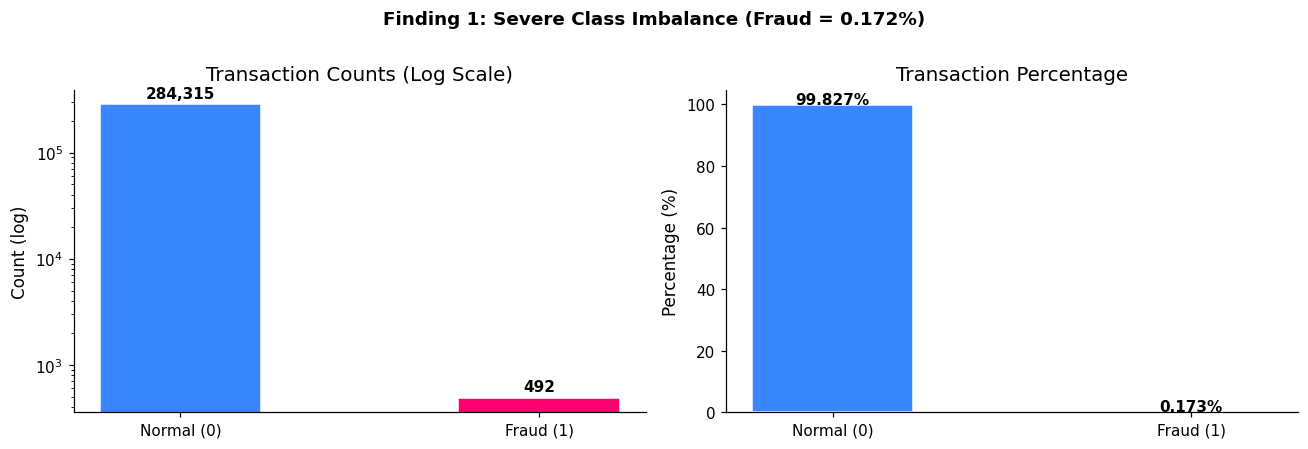


⚠️  Standard accuracy is MISLEADING on this dataset.
   A model predicting everything as normal gets 99.83% accuracy but catches 0 fraud.
   → Use Precision, Recall, F1, PR-AUC as primary metrics.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Log-scale bar to make fraud visible
counts = df["Class"].value_counts().sort_index()
bars = axes[0].bar(["Normal (0)", "Fraud (1)"], counts.values,
                   color=[PALETTE["normal"], PALETTE["fraud"]],
                   edgecolor="white", width=0.45)
axes[0].set_yscale("log")
axes[0].set_title("Transaction Counts (Log Scale)")
axes[0].set_ylabel("Count (log)")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v * 1.15, f"{v:,}",
                 ha="center", fontsize=10, fontweight="bold")

# Percentage
pcts = counts / len(df) * 100
axes[1].bar(["Normal (0)", "Fraud (1)"], pcts.values,
            color=[PALETTE["normal"], PALETTE["fraud"]],
            edgecolor="white", width=0.45)
axes[1].set_title("Transaction Percentage")
axes[1].set_ylabel("Percentage (%)")
for bar, v in zip(axes[1].patches, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2, f"{v:.3f}%",
                 ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Finding 1: Severe Class Imbalance (Fraud = 0.172%)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n⚠️  Standard accuracy is MISLEADING on this dataset.")
print("   A model predicting everything as normal gets 99.83% accuracy but catches 0 fraud.")
print("   → Use Precision, Recall, F1, PR-AUC as primary metrics.")


## 2.3 Transaction Amount Analysis — Finding 2

In [43]:
# ── Summary statistics ──────────────────────────────────────────────────────────
amount_stats = df.groupby("Class")["Amount"].agg([
    "min", "median", "mean", "std", "max", lambda x: x.quantile(0.95)
]).round(2)
amount_stats.columns = ["min", "median", "mean", "std", "max", "95th_pct"]
amount_stats.index = ["Normal", "Fraud"]
amount_stats


,min,median,mean,std,max,95th_pct
Normal,0.0000,22.0000,88.2900,250.1100,25691.1600,364.4100
Fraud,0.0000,9.2500,122.2100,256.6800,2125.8700,640.9000


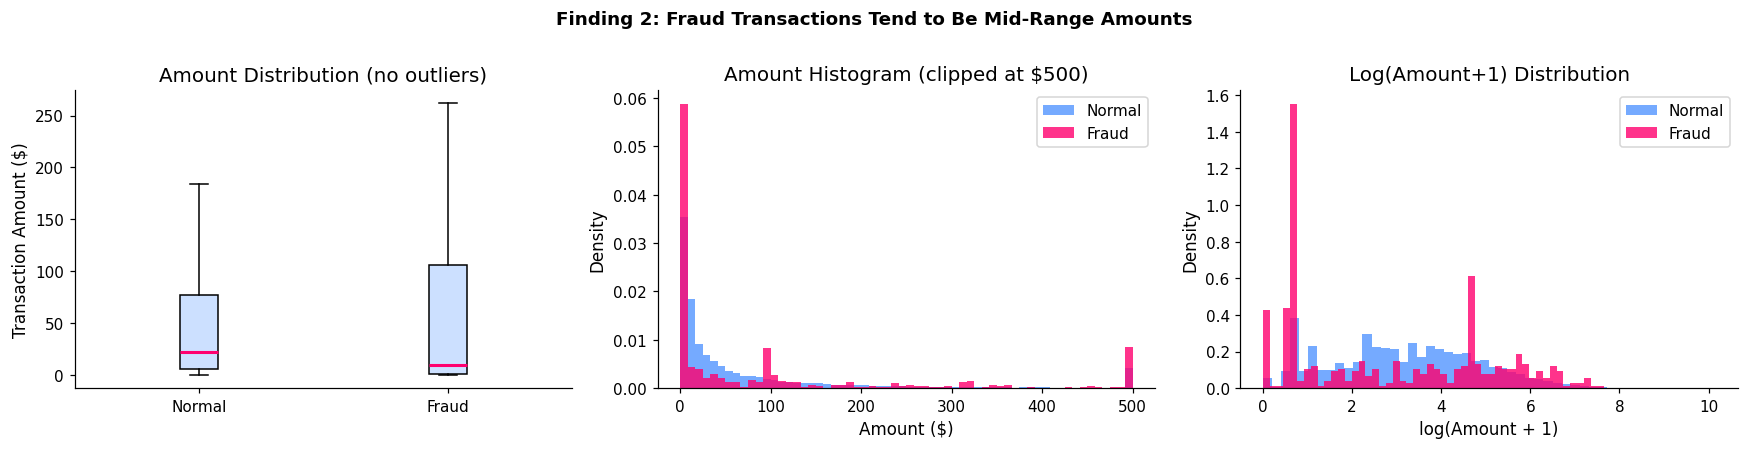

Insight: Fraud transactions cluster in the $1–$500 range.
Very large normal transactions (bills, business payments) are rare in fraud.
→ Log-transform Amount before modeling to reduce skew.


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Boxplot (no outliers for readability)
axes[0].boxplot(
    [normal_df["Amount"], fraud_df["Amount"]],
    labels=["Normal", "Fraud"],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="#cce0ff"),
    medianprops=dict(color="#ff006e", linewidth=2)
)
axes[0].set_title("Amount Distribution (no outliers)")
axes[0].set_ylabel("Transaction Amount ($)")

# Histogram — raw
axes[1].hist(normal_df["Amount"].clip(upper=500), bins=60,
             alpha=0.7, color=PALETTE["normal"], label="Normal", density=True)
axes[1].hist(fraud_df["Amount"].clip(upper=500), bins=60,
             alpha=0.8, color=PALETTE["fraud"], label="Fraud", density=True)
axes[1].set_title("Amount Histogram (clipped at $500)")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Density")
axes[1].legend()

# Log-transformed amount
df["LogAmount"] = np.log1p(df["Amount"])
axes[2].hist(df[df["Class"]==0]["LogAmount"], bins=50,
             alpha=0.7, color=PALETTE["normal"], label="Normal", density=True)
axes[2].hist(df[df["Class"]==1]["LogAmount"], bins=50,
             alpha=0.8, color=PALETTE["fraud"], label="Fraud", density=True)
axes[2].set_title("Log(Amount+1) Distribution")
axes[2].set_xlabel("log(Amount + 1)")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.suptitle("Finding 2: Fraud Transactions Tend to Be Mid-Range Amounts",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Insight: Fraud transactions cluster in the $1–$500 range.")
print("Very large normal transactions (bills, business payments) are rare in fraud.")
print("→ Log-transform Amount before modeling to reduce skew.")


## 2.4 Time Patterns — Finding 3

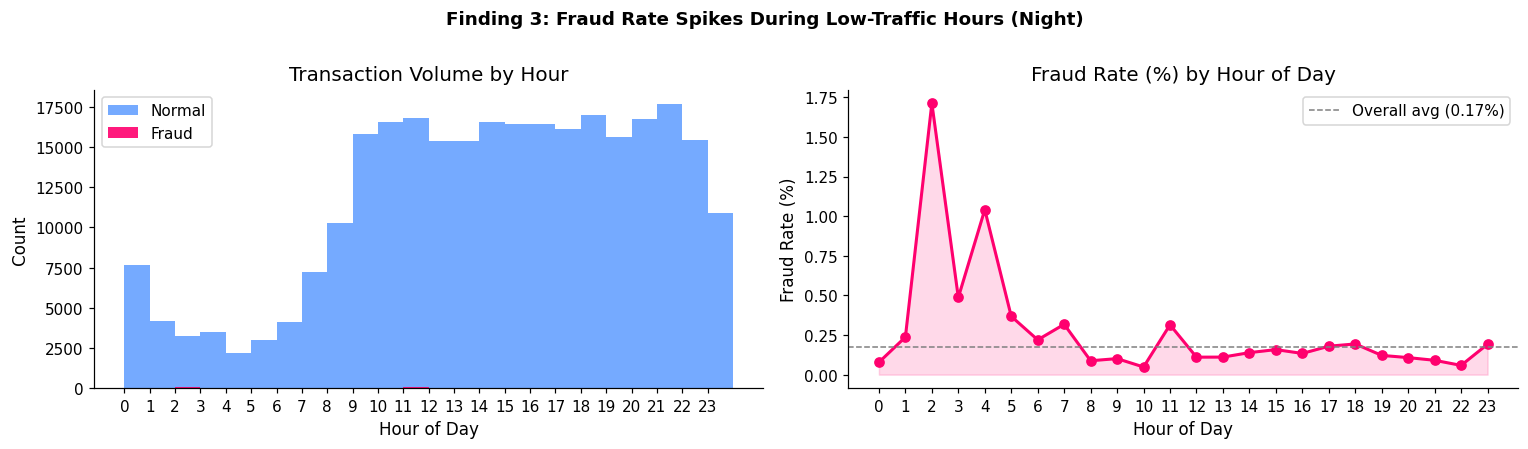

Insight: Fraud rate is elevated during late-night / early-morning hours
when transaction volume is lowest — potentially easier to slip through.
→ Include 'Hour' as an engineered feature.


In [35]:
# Convert seconds to hour-of-day (assuming ~2 days of data)
df["Hour"] = (df["Time"] / 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Transaction volume by hour
axes[0].hist(df[df["Class"]==0]["Hour"], bins=24, alpha=0.7,
             color=PALETTE["normal"], label="Normal", range=(0, 24))
axes[0].hist(df[df["Class"]==1]["Hour"], bins=24, alpha=0.9,
             color=PALETTE["fraud"], label="Fraud", range=(0, 24))
axes[0].set_title("Transaction Volume by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Fraud rate by hour
hourly = df.groupby(df["Hour"].astype(int))["Class"].agg(["count", "sum"])
hourly["fraud_rate"] = hourly["sum"] / hourly["count"] * 100

axes[1].plot(hourly.index, hourly["fraud_rate"], marker="o",
             color=PALETTE["fraud"], linewidth=2, markersize=6)
axes[1].fill_between(hourly.index, hourly["fraud_rate"],
                     alpha=0.15, color=PALETTE["fraud"])
axes[1].set_title("Fraud Rate (%) by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xticks(range(0, 24))
axes[1].axhline(df["Class"].mean()*100, linestyle="--",
                color="gray", linewidth=1, label=f"Overall avg ({df['Class'].mean()*100:.2f}%)")
axes[1].legend()

plt.suptitle("Finding 3: Fraud Rate Spikes During Low-Traffic Hours (Night)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Insight: Fraud rate is elevated during late-night / early-morning hours")
print("when transaction volume is lowest — potentially easier to slip through.")
print("→ Include 'Hour' as an engineered feature.")


## 2.5 PCA Feature Separation — Finding 4

In [36]:
pca_cols = [c for c in df.columns if c.startswith("V")]

# Mean difference between classes
feature_means = df.groupby("Class")[pca_cols].mean().T
feature_means.columns = ["Normal_Mean", "Fraud_Mean"]
feature_means["AbsDiff"] = (feature_means["Fraud_Mean"] - feature_means["Normal_Mean"]).abs()
feature_means = feature_means.sort_values("AbsDiff", ascending=False)

print("Top 10 PCA features by absolute mean difference (Normal vs Fraud):")
feature_means.head(10).round(4)


Top 10 PCA features by absolute mean difference (Normal vs Fraud):


,Normal_Mean,Fraud_Mean,AbsDiff
V3,0.0122,-7.0333,7.0455
V14,0.0121,-6.9717,6.9838
V17,0.0115,-6.6658,6.6774
V12,0.0108,-6.2594,6.2702
V10,0.0098,-5.6769,5.6867
V7,0.0096,-5.5687,5.5784
V1,0.0083,-4.7719,4.7802
V4,-0.0079,4.5420,4.5499
V16,0.0072,-4.1399,4.1471
V11,-0.0066,3.8002,3.8067


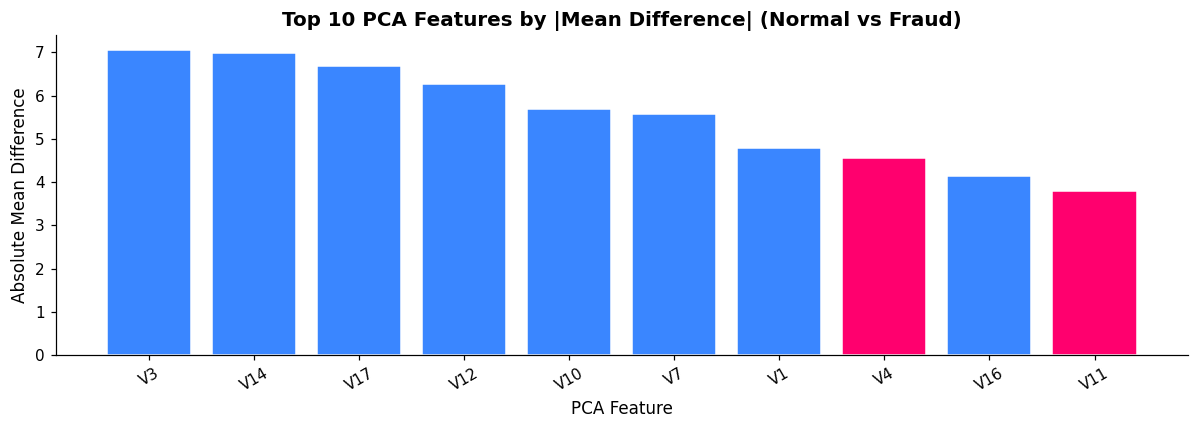

In [37]:
# ── Bar chart of top features ───────────────────────────────────────────────────
top10 = feature_means.head(10)

fig, ax = plt.subplots(figsize=(11, 4))
colors = [PALETTE["fraud"] if diff > 0 else PALETTE["normal"]
          for diff in (top10["Fraud_Mean"] - top10["Normal_Mean"])]
ax.bar(top10.index, top10["AbsDiff"], color=colors, edgecolor="white")
ax.set_title("Top 10 PCA Features by |Mean Difference| (Normal vs Fraud)",
             fontweight="bold")
ax.set_xlabel("PCA Feature")
ax.set_ylabel("Absolute Mean Difference")
ax.set_xticklabels(top10.index, rotation=30)
plt.tight_layout()
plt.show()


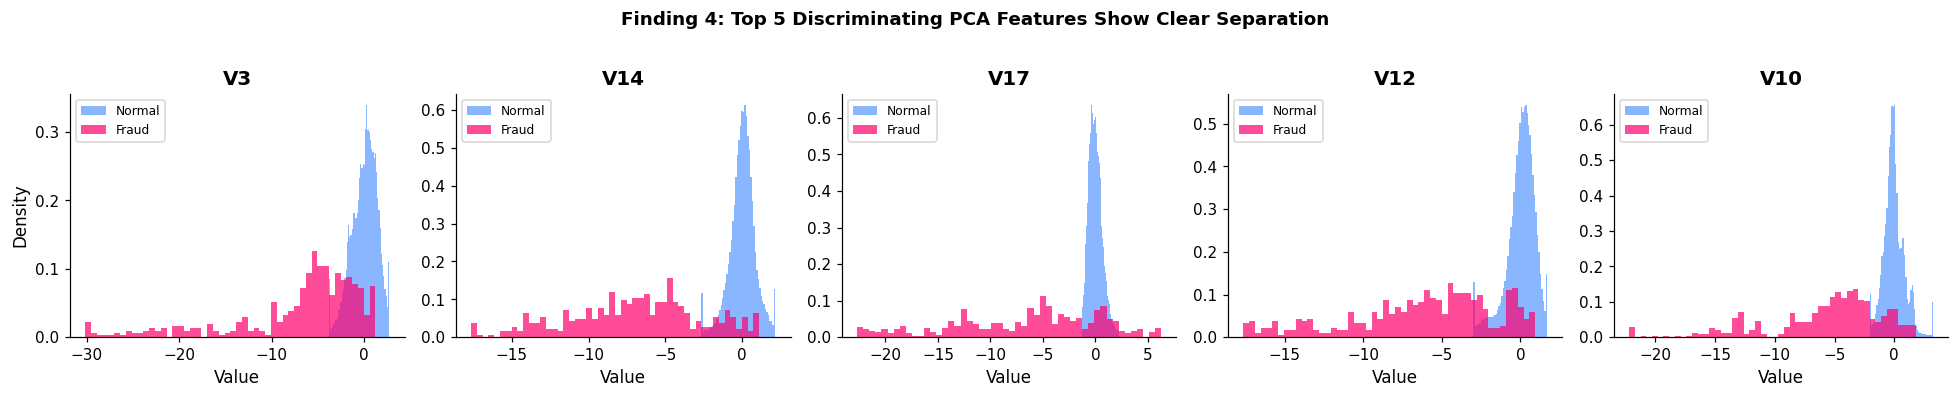

In [38]:
# ── KDE plots for top 5 discriminating features ─────────────────────────────────
top5 = feature_means.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

for ax, feat in zip(axes, top5):
    normal_data = normal_df[feat].clip(
        normal_df[feat].quantile(0.01), normal_df[feat].quantile(0.99))
    fraud_data = fraud_df[feat].clip(
        fraud_df[feat].quantile(0.01), fraud_df[feat].quantile(0.99))

    ax.hist(normal_data, bins=50, alpha=0.6, color=PALETTE["normal"],
            density=True, label="Normal")
    ax.hist(fraud_data, bins=50, alpha=0.7, color=PALETTE["fraud"],
            density=True, label="Fraud")
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("Value")
    if ax == axes[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Finding 4: Top 5 Discriminating PCA Features Show Clear Separation",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 2.6 Correlation Analysis — Finding 5

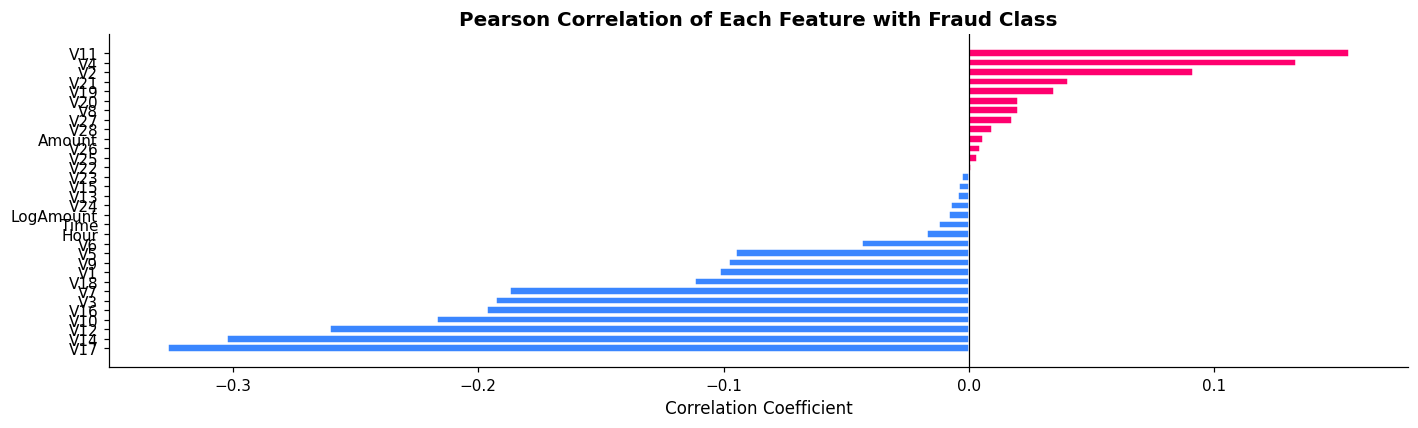

Most positively correlated with fraud:
V19   0.0348
V21   0.0404
V2    0.0913
V4    0.1334
V11   0.1549
dtype: float64

Most negatively correlated with fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
dtype: float64


In [39]:
# Correlation with target Class
corr = df[pca_cols + ["Amount", "Time", "LogAmount", "Hour"]].corrwith(df["Class"]).sort_values()

fig, ax = plt.subplots(figsize=(13, 4))
colors = [PALETTE["fraud"] if v > 0 else PALETTE["normal"] for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Each Feature with Fraud Class",
             fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

print("Most positively correlated with fraud:")
print(corr.tail(5).round(4))
print()
print("Most negatively correlated with fraud:")
print(corr.head(5).round(4))


## 2.7 Pairplot — Top 4 Features

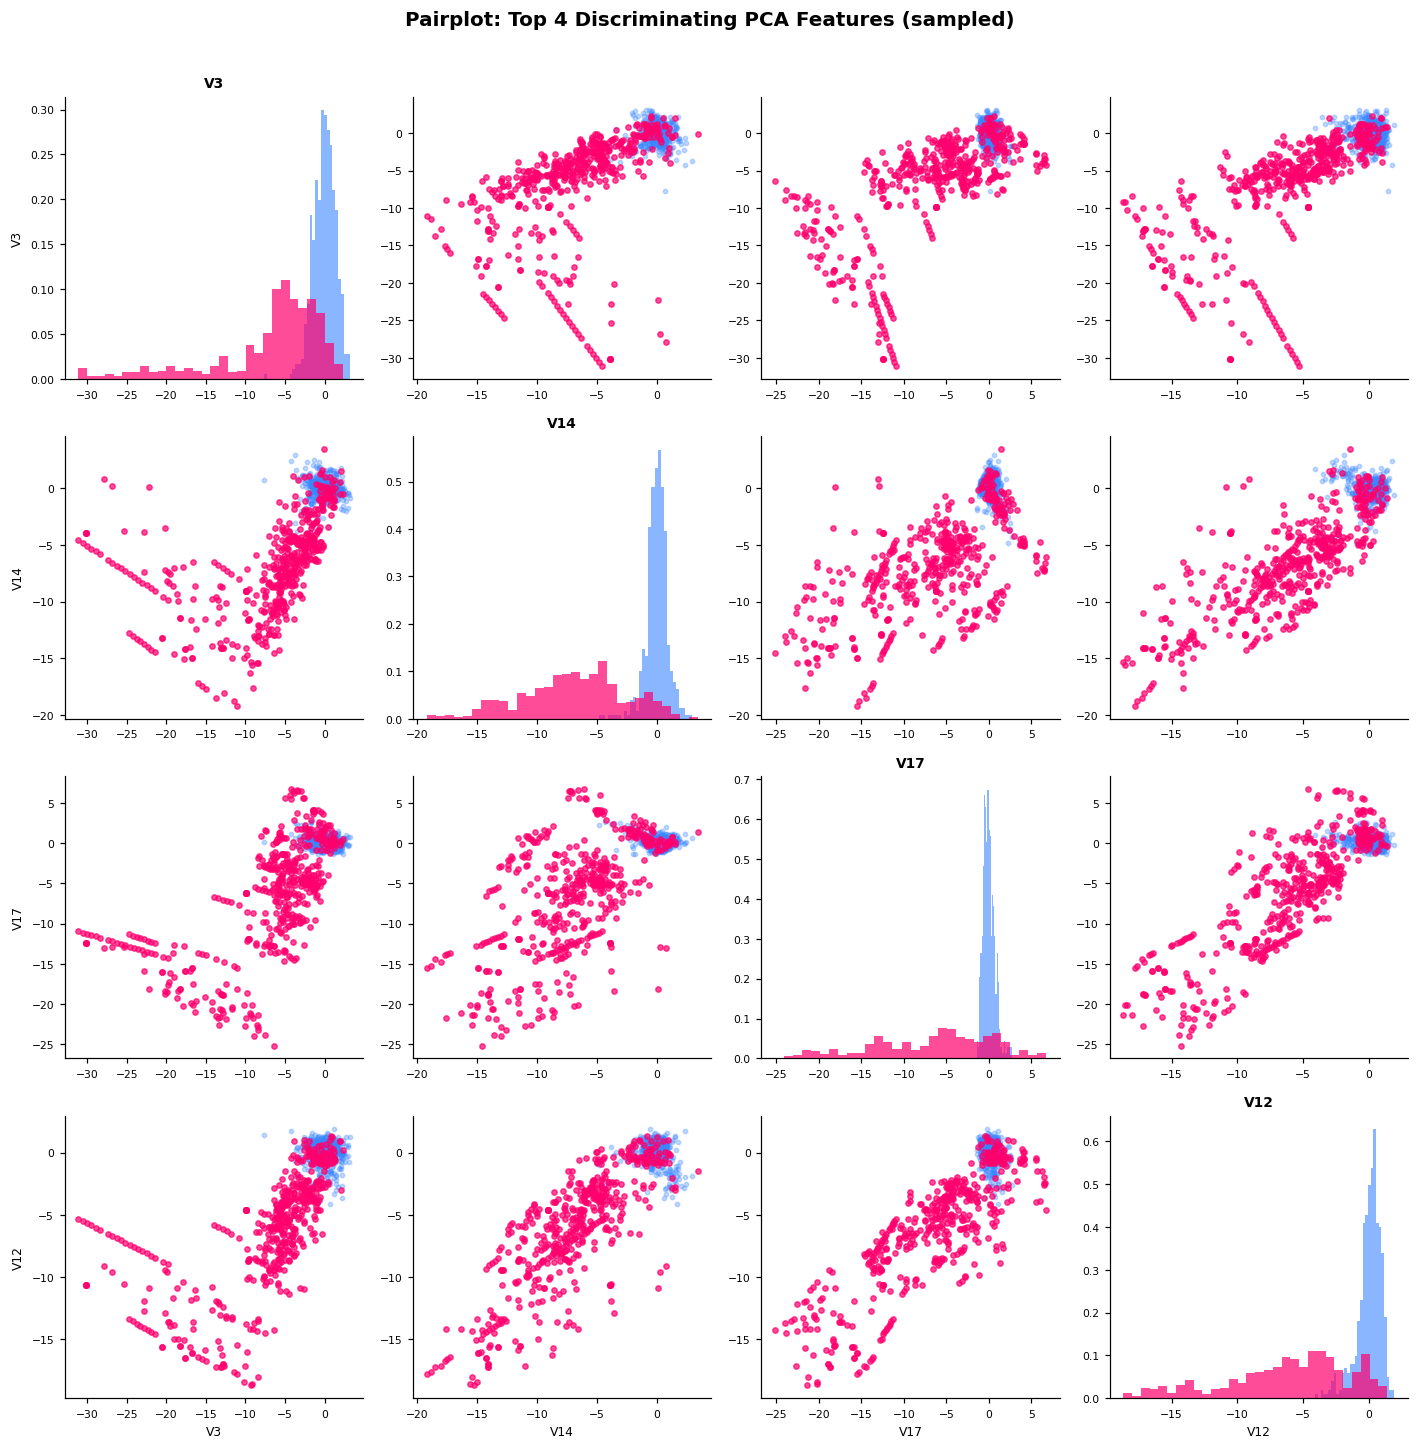

In [40]:
# ── Pairplot: sample to keep it fast ────────────────────────────────────────────
top4 = feature_means.head(4).index.tolist()

sample_normal = normal_df[top4 + ["Class"]].sample(500, random_state=42)
sample_fraud  = fraud_df[top4 + ["Class"]]          # all fraud (492)
sample = pd.concat([sample_normal, sample_fraud])

pair_colors = sample["Class"].map({0: PALETTE["normal"], 1: PALETTE["fraud"]})

fig, axes = plt.subplots(4, 4, figsize=(13, 13))

for i, f1 in enumerate(top4):
    for j, f2 in enumerate(top4):
        ax = axes[i][j]
        if i == j:
            ax.hist(sample[sample["Class"]==0][f1], bins=30, alpha=0.6,
                    color=PALETTE["normal"], density=True)
            ax.hist(sample[sample["Class"]==1][f1], bins=30, alpha=0.7,
                    color=PALETTE["fraud"], density=True)
            ax.set_title(f1, fontsize=9, fontweight="bold")
        else:
            ax.scatter(sample[sample["Class"]==0][f2],
                       sample[sample["Class"]==0][f1],
                       alpha=0.3, s=8, color=PALETTE["normal"], label="Normal")
            ax.scatter(sample[sample["Class"]==1][f2],
                       sample[sample["Class"]==1][f1],
                       alpha=0.7, s=12, color=PALETTE["fraud"], label="Fraud")
        if i == 3: ax.set_xlabel(f2, fontsize=8)
        if j == 0: ax.set_ylabel(f1, fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle("Pairplot: Top 4 Discriminating PCA Features (sampled)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 2.8 Amount vs PCA Feature Scatter (Fraud Highlighted)

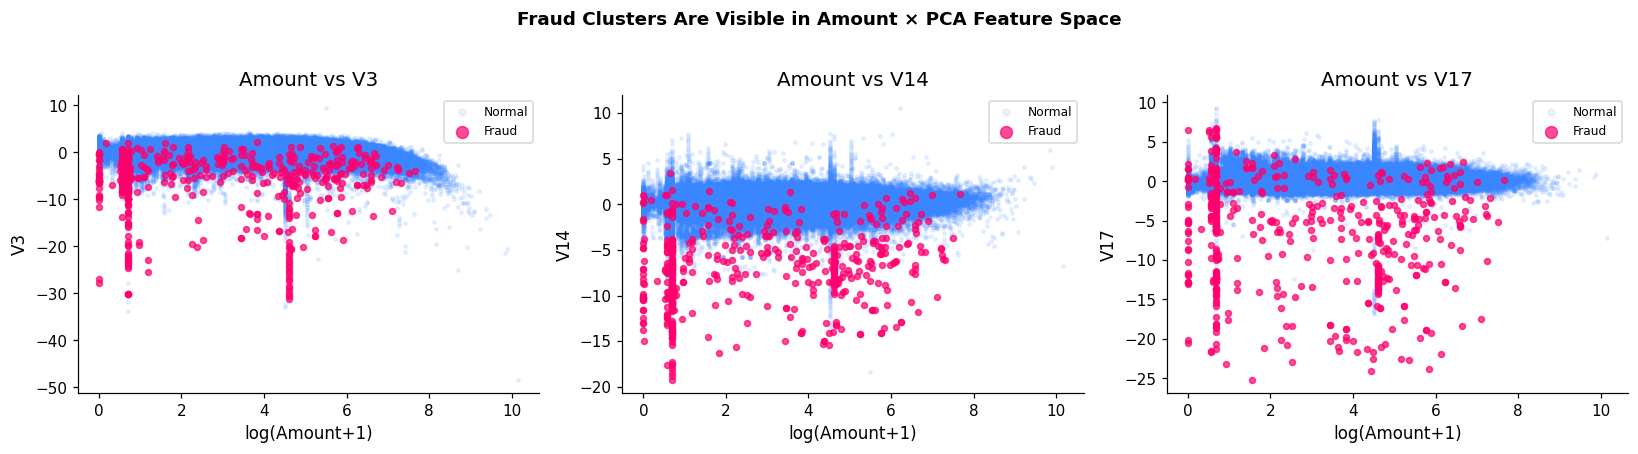

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

top3 = feature_means.head(3).index.tolist()

for ax, feat in zip(axes, top3):
    ax.scatter(normal_df["LogAmount"], normal_df[feat],
               alpha=0.1, s=5, color=PALETTE["normal"], label="Normal")
    ax.scatter(fraud_df["LogAmount"], fraud_df[feat],
               alpha=0.7, s=15, color=PALETTE["fraud"], label="Fraud", zorder=5)
    ax.set_xlabel("log(Amount+1)")
    ax.set_ylabel(feat)
    ax.set_title(f"Amount vs {feat}")
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle("Fraud Clusters Are Visible in Amount × PCA Feature Space",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 2.9 Save EDA Feature File

In [42]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

save_path = PROCESSED_DIR / "creditcard_eda_features.csv"
df.to_csv(save_path, index=False)

print(f"Saved EDA-enhanced dataset to: {save_path}")
print(f"New columns added: Hour, LogAmount")


Saved EDA-enhanced dataset to: ../data/processed/creditcard_eda_features.csv
New columns added: Hour, LogAmount


## EDA Summary

| Finding | Observation | Modeling Implication |
|---|---|---|
| **1. Class Imbalance** | Fraud = 0.172% of transactions | Use Precision/Recall/F1/PR-AUC, not accuracy |
| **2. Amount Skew** | Fraud clusters at mid-range; large txns are mostly normal | Log-transform Amount; scale before modeling |
| **3. Time Pattern** | Fraud spikes during low-traffic hours | Include `Hour` as engineered feature |
| **4. PCA Separation** | V4, V11, V12, V14, V17 strongly separate classes | These features should carry most model weight |
| **5. Correlations** | Several V features are strongly correlated with Class | Logistic Regression should work as baseline; tree models may outperform |

### Modeling Plan
| Model | Role | Why |
|---|---|---|
| Logistic Regression | Baseline | Simple, fast, interpretable |
| Decision Tree | Baseline | Nonlinear, no scaling needed |
| Random Forest | Baseline | Strong ensemble benchmark |
| **Gradient Boosting** | **Main supervised** | Best at imbalanced nonlinear classification |
| **Autoencoder** | **Main anomaly detector** | Learns normal behavior; flags outliers |
| **Hybrid** | **Best of both** | Combines supervised probability + anomaly score |

**Next step →** `3_preprocessing_and_labeling.ipynb`
